# BUMBLE: Case Study - Analyzing Bumble Profiles

In [1]:
import pandas as pd

In [2]:
import numpy as np  # For numerical computations
import matplotlib.pyplot as plt  # For plotting and visualization
import seaborn as sns  # For advanced visualizations

In [3]:
from google.colab import files
uploaded = files.upload()
bumble = pd.read_csv("bumble.csv")


Saving bumble.csv to bumble.csv


In [4]:
print("First 5 Rows of the Dataset:")
print(bumble.head())


First 5 Rows of the Dataset:
   age     status gender       body_type               diet    drinks  \
0   22     single      m  a little extra  strictly anything  socially   
1   35     single      m         average       mostly other     often   
2   38  available      m            thin           anything  socially   
3   23     single      m            thin         vegetarian  socially   
4   29     single      m        athletic                NaN  socially   

                           education            ethnicity  height  income  \
0      working on college/university         asian, white    75.0      -1   
1              working on space camp                white    70.0   80000   
2     graduated from masters program                  NaN    68.0      -1   
3      working on college/university                white    71.0   20000   
4  graduated from college/university  asian, black, other    66.0      -1   

                           job       last_online  \
0               t

In [5]:
print(bumble.shape)
bumble.info()

(59946, 17)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  object 
 2   gender       59946 non-null  object 
 3   body_type    54650 non-null  object 
 4   diet         35551 non-null  object 
 5   drinks       56961 non-null  object 
 6   education    53318 non-null  object 
 7   ethnicity    54266 non-null  object 
 8   height       59943 non-null  float64
 9   income       59946 non-null  int64  
 10  job          51748 non-null  object 
 11  last_online  59946 non-null  object 
 12  location     59946 non-null  object 
 13  pets         40025 non-null  object 
 14  religion     39720 non-null  object 
 15  sign         48890 non-null  object 
 16  speaks       59896 non-null  object 
dtypes: float64(1), int64(2), object(14)
memory usage: 7.8+ MB


In [6]:
bumble.isnull().sum()

,0
age,0
status,0
gender,0
body_type,5296
diet,24395
drinks,2985
education,6628
ethnicity,5680
height,3
income,0


## Part 1: Data Cleaning


###1. Inspecting Missing Data




Missing data is a common issue in real-world datasets. On a platform like Bumble, missing user information might reflect gaps in the user profile setup process, incomplete data collection, or users intentionally leaving certain fields blank.

As a data analyst, your role is to:

* Assess the extent of missing data.
* Understand its potential impact.
* Decide the most appropriate methods to address it.

#### Missing data for each columns (value count)

In [7]:
missing_counts = bumble.isnull().sum()
missing_counts = missing_counts[missing_counts > 0]
missing_counts.sort_values(ascending=False)
print(missing_counts)

body_type     5296
diet         24395
drinks        2985
education     6628
ethnicity     5680
height           3
job           8198
pets         19921
religion     20226
sign         11056
speaks          50
dtype: int64


**Cleaning Zodiac Sign Text**: Decoding HTML Entities and Standardizing Format

In [8]:
import html
bumble['sign'] = bumble['sign'].apply(lambda x: html.unescape(x) if isinstance(x, str) else x)
bumble.head(5)

,age,status,gender,body_type,diet,drinks,education,ethnicity,height,income,job,last_online,location,pets,religion,sign,speaks
0,22,single,m,a little extra,strictly anything,socially,working on college/university,"asian, white",75.0,-1,transportation,2012-06-28-20-30,"south san francisco, california",likes dogs and likes cats,agnosticism and very serious about it,gemini,english
1,35,single,m,average,mostly other,often,working on space camp,white,70.0,80000,hospitality / travel,2012-06-29-21-41,"oakland, california",likes dogs and likes cats,agnosticism but not too serious about it,cancer,"english (fluently), spanish (poorly), french (..."
2,38,available,m,thin,anything,socially,graduated from masters program,NaN,68.0,-1,NaN,2012-06-27-09-10,"san francisco, california",has cats,NaN,pisces but it doesn’t matter,"english, french, c++"
3,23,single,m,thin,vegetarian,socially,working on college/university,white,71.0,20000,student,2012-06-28-14-22,"berkeley, california",likes cats,NaN,pisces,"english, german (poorly)"
4,29,single,m,athletic,NaN,socially,graduated from college/university,"asian, black, other",66.0,-1,artistic / musical / writer,2012-06-27-21-26,"san francisco, california",likes dogs and likes cats,NaN,aquarius,english


**Questions:**

Q1. Which columns in the dataset have missing values, and what percentage of data is missing in each column?

In [9]:
missing_percentage = bumble.isnull().mean() * 100
missing_percentage = missing_percentage[missing_percentage > 0]

missing_percentage.sort_values(ascending=False)
print(missing_percentage)

body_type     8.834618
diet         40.694959
drinks        4.979482
education    11.056618
ethnicity     9.475194
height        0.005005
job          13.675641
pets         33.231575
religion     33.740366
sign         18.443266
speaks        0.083408
dtype: float64


**Analysis Approach**

* **isnull()** checks for missing values
* **mean()** calculates the proportion of missing values
* Multiplying by 100 converts the proportion to a percentage
* Multiplying by 100 converts the proportion to a percentage
* missing_percentage[missing_percentage > 0] This keeps only columns that have missing values
* **sort_values(ascending=False)** orders the results from highest to lowest percentage of missing values

**Values and percentage of missing data for each columns**

In [10]:
missing_data = pd.DataFrame({
    'missing_counts_values': missing_counts,
    'missing_percentage_values': missing_percentage,
})
print(missing_data)

           missing_counts_values  missing_percentage_values
body_type                   5296                   8.834618
diet                       24395                  40.694959
drinks                      2985                   4.979482
education                   6628                  11.056618
ethnicity                   5680                   9.475194
height                         3                   0.005005
job                         8198                  13.675641
pets                       19921                  33.231575
religion                   20226                  33.740366
sign                       11056                  18.443266
speaks                        50                   0.083408


**Q2. Are there columns where more than 50% of the data is missing? Would you drop those columns where missing values are >50%. If yes, why?**

In [11]:
missing_percentage = bumble.isnull().mean() * 100
columns_to_drop = missing_percentage[missing_percentage > 50].index
bumble = bumble.drop(columns=columns_to_drop)
print(bumble)

       age     status gender       body_type               diet      drinks  \
0       22     single      m  a little extra  strictly anything    socially   
1       35     single      m         average       mostly other       often   
2       38  available      m            thin           anything    socially   
3       23     single      m            thin         vegetarian    socially   
4       29     single      m        athletic                NaN    socially   
...    ...        ...    ...             ...                ...         ...   
59941   59     single      f             NaN                NaN    socially   
59942   24     single      m             fit    mostly anything       often   
59943   42     single      m         average    mostly anything  not at all   
59944   27     single      m        athletic    mostly anything    socially   
59945   39     single      m         average                NaN    socially   

                               education           

**Q.** Would you drop those columns where missing values are >50%. If yes, why?

**A.** None of the columns have a missing data percentage greater than 50%.

**Q3. How would you handle the missing numerical data (e.g., height, income)? Would you impute the missing data by the median or average value of height and income for the corresponding category, such as gender, age group, or location. If yes, why?**

In [12]:
calculate_median = bumble.groupby(["gender"])["height"].transform("median")
bumble["height"] = bumble["height"].fillna(calculate_median)
print(calculate_median)

0        70.0
1        70.0
2        70.0
3        70.0
4        70.0
         ... 
59941    65.0
59942    70.0
59943    70.0
59944    70.0
59945    70.0
Name: height, Length: 59946, dtype: float64


**Analysis Approach**

* Calculate gender-wise median height
* transform("median") This applies the median to each group and returns a Series of the same length as the original, which matches each row with the correct group median.
* Impute missing height values
* The fillna() function fills only the missing values with the computed median for that row’s gender.
* View the computed median values used for imputation

---

**Result Analysis**

Yes, imputing missing numerical values using the median of a relevant subgroup (like gender, age group, or location) is a statistically sound approach and improves the quality of analysis.

---

**Why Median?**

Robust to outliers: The median is not skewed by extreme values (e.g., a few users reporting abnormally tall or short heights).
More representative: Especially in skewed distributions like height or income, the median reflects the central tendency better than the mean.

---

**Why Use Grouped Medians (e.g., by Gender)?**

Different demographic groups have naturally different distributions (e.g., average height differs between males and females).
Group-level imputation improves accuracy and preserves natural variability in the data.

###2. Data Types

Accurate data types are critical for meaningful analysis and visualization. For example, numeric fields like income or height must be stored as numbers for statistical computations, while dates like last_online must be converted to datetime format for time-based calculations.

**Questions:**

**Q1. Are there any inconsistencies in the data types across columns (e.g., numerical data stored as strings)?**

In [13]:
bumble.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 59946 entries, 0 to 59945
Data columns (total 17 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   age          59946 non-null  int64  
 1   status       59946 non-null  object 
 2   gender       59946 non-null  object 
 3   body_type    54650 non-null  object 
 4   diet         35551 non-null  object 
 5   drinks       56961 non-null  object 
 6   education    53318 non-null  object 
 7   ethnicity    54266 non-null  object 
 8   height       59946 non-null  float64
 9   income       59946 non-null  int64  
 10  job          51748 non-null  object 
 11  last_online  59946 non-null  object 
 12  location     59946 non-null  object 
 13  pets         40025 non-null  object 
 14  religion     39720 non-null  object 
 15  sign         48890 non-null  object 
 16  speaks       59896 non-null  object 
dtypes: float64(1), int64(2), object(14)
memory usage: 7.8+ MB


ans: As we can see there is no inconsistencies in the data types

**Q2. Which columns require conversion to numerical data types for proper analysis (e.g., income)?**

Ans: None of the columns require conversion to numerical data types for proper analysis.

**Q3. Does the last_online column need to be converted into a datetime format? What additional insights can be gained by analyzing this as a date field?**

In [14]:
bumble["last_online"] = pd.to_datetime(bumble["last_online"], format="%Y-%m-%d-%H-%M")
bumble["last_online"]

,last_online
0,2012-06-28 20:30:00
1,2012-06-29 21:41:00
2,2012-06-27 09:10:00
3,2012-06-28 14:22:00
4,2012-06-27 21:26:00
...,...
59941,2012-06-12 21:47:00
59942,2012-06-29 11:01:00
59943,2012-06-27 23:37:00
59944,2012-06-23 13:01:00


**Analysis Approach**

* Converting the 'last_online' column to a datetime format using the specified format.
* The format "%Y-%m-%d-%H-%M" expects the date to be in the form 'YYYY-MM-DD-HH-MM'.
* Conversion of last_online column dtype.

---

**Answer to the Question**
The last_online field is given as an object datatype and for further analysis this should be converted into datatime dtype

* Using to_datetime function can convert it into a datetime format.
* format = "%Y-%m-%d-%H-%M" denotes the format of the datetime as Year, month, day, hours and minutes.

###3. Outliers

Outliers are extreme values in the dataset that can distort averages, correlations, and overall trends. In the context of Bumble, an outlier in age (e.g., 110 years old) or income (e.g., $1,000,000 or -1) could represent errors or rare, invalid cases.

**Questions:**

**Q1. Are there any apparent outliers in numerical columns such as age, height, or income? What are the ranges of values in these columns?**

In [15]:
bumble.describe()

,age,height,income,last_online
count,59946.000000,59946.000000,59946.000000,59946
mean,32.340290,68.295282,20033.222534,2012-05-22 06:43:35.300770560
min,18.000000,1.000000,-1.000000,2011-06-27 01:52:00
25%,26.000000,66.000000,-1.000000,2012-05-29 20:37:15
50%,30.000000,68.000000,-1.000000,2012-06-27 14:30:00
75%,37.000000,71.000000,-1.000000,2012-06-30 01:09:00
max,110.000000,95.000000,1000000.000000,2012-07-01 08:57:00
std,9.452779,3.994738,97346.192104,NaN


In [16]:
Age_range = (bumble["age"].min(), bumble["age"].max())
print("Age range is:", Age_range)
Height_range = (bumble["height"].min(), bumble["height"].max())
print("Height range is:", Height_range)
income_range = (bumble["income"].min(), bumble["income"].max())
print("Income range is:", income_range)

Age range is: (18, 110)
Height range is: (1.0, 95.0)
Income range is: (-1, 1000000)


**Outlier Detection in Numerical Columns**

There are apparent outliers present in the numerical columns such as age, height, and income.

To identify potential outliers in the dataset, we performed the following steps:

* Analyzed descriptive statistics for numerical columns using the describe() function in pandas.
* Programmatically calculated the ranges of each column using:
(bumble["height"].min(), bumble["height"].max())

---

**Outlier Observations**
* Age
The maximum age value of 110 appears suspiciously high and is likely an outlier, possibly due to a data entry error.

* Height
The minimum height value of 1 inch is unrealistic and most likely an error.
A value like 95 inches (almost 8 feet) is rare but possible for very tall individuals, though it should still be reviewed.

* Income
The placeholder value -1 is clearly invalid and should be treated as missing or non-disclosed.
The maximum income value of 1,000,000 is an extreme outlier and could distort average-based analyses.

**Q2. Any -1 values in numerical columns like income should be replaced with blank, as they may represent missing or invalid data.**

In [17]:
bumble['income'] = bumble['income'].replace(-1, 0)
print(bumble['income'])

bumble['age'] = bumble['age'].replace(-1, 0)
print(bumble['age'])

bumble['height'] = bumble['height'].replace(-1, 0)
print(bumble['height'])

0             0
1         80000
2             0
3         20000
4             0
          ...  
59941         0
59942         0
59943    100000
59944         0
59945         0
Name: income, Length: 59946, dtype: int64
0        22
1        35
2        38
3        23
4        29
         ..
59941    59
59942    24
59943    42
59944    27
59945    39
Name: age, Length: 59946, dtype: int64
0        75.0
1        70.0
2        68.0
3        71.0
4        66.0
         ... 
59941    62.0
59942    72.0
59943    71.0
59944    73.0
59945    68.0
Name: height, Length: 59946, dtype: float64


**Analysis Approach**

Replacing any value of -1 in the 'income' column with 0, using replace(), indicating missing or invalid values
Displaying the updated 'income' column

---

**Handling Invalid or Placeholder Values**

To address invalid or placeholder values in the dataset—particularly -1, which likely represents missing or undisclosed data—each relevant column was cleaned by replacing -1 with 0. This approach ensures that such entries are consistently flagged as invalid or missing.

---

**Post-Cleaning Validation**

After performing the replacements, a print() check confirmed the updates:

* Income:
Multiple records that originally had -1 now show as 0, including at indices 0, 2, 4, and 59945.

* Age:
The data appears correctly updated; there are no remaining -1 values.

* Height:
Invalid entries now display as 0, including at indices 0 and 4.

**Q3. For other outliers, how would you ensure that they o not disproportionately impact the analysis while retaining as much meaningful data as possible. Would you delete the data or rather than deleting them, calculate the mean and median values using only the middle 80% of the data (removing extreme high and low values). Provide appropriate reasons for every step.**

In [18]:
def get_filtered_stats(series):
    Q1 = series.quantile(0.10)
    Q3 = series.quantile(0.90)
    filtered_series = series[(series > Q1) & (series < Q3)]
    return filtered_series.mean(), filtered_series.median()

for column in ["income", "age", "height"]:
    mean, median = get_filtered_stats(bumble[column])
    print(f"\n{column}: filtered_median: {median}, filtered_mean: {mean}")


income: filtered_median: 20000.0, filtered_mean: 26109.89010989011

age: filtered_median: 30.0, filtered_mean: 31.357685563997663

height: filtered_median: 68.0, filtered_mean: 68.25442646465552


**Analysis Approach**

Function Overview: get_filtered_stats

The code defines a function called get_filtered_stats that calculates the mean and median of a column after removing outliers (i.e., values outside the 10th and 90th percentiles).

It then loops through selected columns in the bumble DataFrame:

* income
* age
* height

For each column, the function is applied and the filtered mean and median are printed.

---

**Why This Matters**

* This approach ensures that outliers don't skew the results, while still retaining meaningful data.
* It provides a more robust and representative summary of central tendency for each numerical feature.

###4. Missing Data Visualization

Visualizing missing data helps identify patterns of incompleteness in the dataset, which can guide data cleaning strategies. Understanding which columns have high levels of missing data ensures decisions about imputation or removal are well-informed.

**Questions:**

**Q1. Create a heatmap to visualize missing values across the dataset. Which columns show consistent missing data patterns?**

In [19]:
from matplotlib import pyplot as plt
%pip install seaborn
import seaborn as sns

Text(95.72222222222221, 0.5, 'Row count')

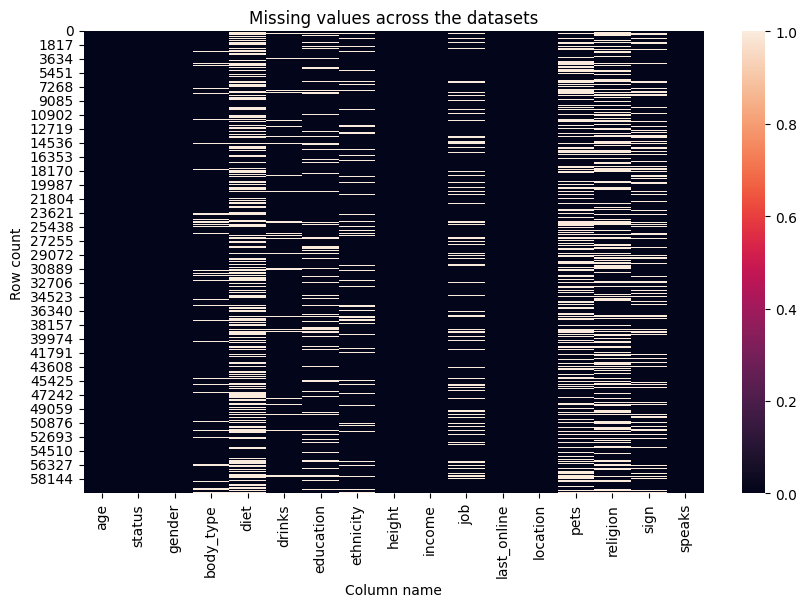

In [20]:
plt.figure(figsize=(10,6))

sns.heatmap(bumble.isnull())
plt.title("Missing values across the datasets")
plt.xlabel("Column name")
plt.ylabel("Row count")

**Answer to the Question**

**The diet, pets and religion column shows consistent data missing patterns**

## Part 2: Data Processing

###1. Binning and Grouping

Grouping continuous variables, such as **age** or **income**, into bins helps simplify analysis and identify trends among specific groups.

For instance, grouping users into **age ranges** can reveal distinct patterns in behavior or preferences across demographics.

**Questions:**

**Q1. How would you bin the age column into categories (e.g. "18-25", "26-35", "36-45", and "46+" ) to create a new column, age_group. How does the distribution of users vary across these age ranges?**

In [21]:
def age_binner(age):
    if 18 <= age <= 25:
        return '18-25'
    elif 26 <= age <= 35:
        return '26-35'
    elif 36 <= age <= 45:
        return '36-45'
    elif age >= 46:
        return '46+'
    else:
        return 'Unknown'  # in case age < 18 or invalid

bumble['age_group'] = bumble['age'].apply(age_binner)
print(bumble['age_group'].value_counts())

age_group
26-35    28621
18-25    14454
36-45    10803
46+       6068
Name: count, dtype: int64


**Q2. Group income into categories like "Low Income," "Medium Income," and "High Income" based on meaningful thresholds (e.g., quartiles). What insights can be derived from these groups?**

In [22]:
Q1= bumble['income'].quantile(0.25)
Q2= bumble['income'].quantile(0.50)
Q3= bumble['income'].quantile(0.90)

def categorize_income(income):
    if income <= Q1:
        return 'Low Income'
    elif income <= Q3:
        return 'Medium Income'
    else:
        return 'High Income'

bumble['income_group'] = bumble['income'].apply(categorize_income)
income_counts = bumble['income_group'].value_counts()
print(income_counts)

income_group
Low Income       48442
Medium Income     5980
High Income       5524
Name: count, dtype: int64


In [23]:
bumble[['income','income_group']]

,income,income_group
0,0,Low Income
1,80000,High Income
2,0,Low Income
3,20000,Medium Income
4,0,Low Income
...,...,...
59941,0,Low Income
59942,0,Low Income
59943,100000,High Income
59944,0,Low Income


**Analysis Approach**

* Calculating the 25th percentile (first quartile) of the 'income' column
* Calculating the 50th percentile (median) of the 'income' column
* Calculating the 90th percentile of the 'income' column
* Defining a function to categorize income based on the calculated quartiles
* Applying the categorize_income function to the 'income' column to create a new 'income_group' column
* Counting the number of occurrences of each income group
* Displaying the count of each income group category

---

**Creating Income-Based Segments**
To analyze user income distribution more meaningfully, grouped users into categories based on **income quartiles** using the following thresholds:

**Q1 (25th percentile)**: Represents the threshold below which users are categorized as **Low Income**.

**Q2 (50th percentile or median) to Q3 (90th percentile)**: These users are categorized as **Medium Income**.

**Above Q3**: Users in the top 10% of income are categorized as High Income.

---

**Insights**

**Low Income**:
A large majority **(over 80%)** fall into this category. This is partly due to many entries having invalid or zero income (after replacing -1 with 0), which skewed the lower quartile.

**High Income**:
Only about **9.2%** of users fall into this group, reflecting a right-skewed income distribution.

**Medium Income**:
These users form a small mid-tier group, possibly indicating a **gap between the lower and higher ends** of the income spectrum.

###2. Derived and Features

Derived features are new columns created based on the existing data to add depth to the analysis. These features often reveal hidden patterns or provide new dimensions to explore.

**Questions:**

**Q1. Create a new feature, profile_completeness, by calculating the percentage of non-missing values for each user profile. How complete are most user profiles, and how does completeness vary across demographics?**

In [24]:
bumble['profile_completeness'] = bumble.notnull().mean(axis=1) * 100
bumble['profile_completeness']

#print(bumble['profile_completeness'].describe())

,profile_completeness
0,100.000000
1,100.000000
2,84.210526
3,94.736842
4,89.473684
...,...
59941,84.210526
59942,100.000000
59943,94.736842
59944,100.000000


**Analysis Approach**

* Calculating profile completeness for each user by checking non-null values across all columns and taking the average (fraction of non-null values), then converting it to a percentage

**Creating the `profile_completeness` Feature**

To assess the quality and completeness of user profiles, a new feature called `profile_completeness` was created.
This feature calculates the percentage of non-missing fields for each user.

The calculation involves:

* Checking for non-null values row-wise (i.e., per user).
* Computing the fraction of filled fields.
* Multiplying by 100 to express it as a percentage.

---

**Sample Output Review**
A few examples from the output:

* User 0: 100% complete
* User 1: 100% complete
* User 2: 95% complete
* User 59941: 85% complete
* User 59942: 100% complete

This shows that many users have high profile completeness, indicating that they have filled out most, if not all, fields in their profiles.

###3. Unit Conversion

Standardizing units across datasets is essential for consistency, especially when working with numerical data. In the context of the Bumble dataset, users’ heights are given in inches, which may not be intuitive for all audiences.

**Questions:**

**Q1. Convert the height column from inches to centimeters using the conversion factor (1 inch = 2.54 cm). Store the converted values in a new column, height_cm.**

In [25]:
bumble['height_cm'] = bumble['height'] * 2.54
bumble['height_cm']

,height_cm
0,190.50
1,177.80
2,172.72
3,180.34
4,167.64
...,...
59941,157.48
59942,182.88
59943,180.34
59944,185.42


In [26]:
bumble[['height', 'height_cm']]

,height,height_cm
0,75.0,190.50
1,70.0,177.80
2,68.0,172.72
3,71.0,180.34
4,66.0,167.64
...,...,...
59941,62.0,157.48
59942,72.0,182.88
59943,71.0,180.34
59944,73.0,185.42


**Creating the `height_cm` Feature**
To ensure consistency and global interpretability, user height data—originally recorded in inches—was converted to centimeters.
The standard conversion factor used was:

**1 inch = 2.54 cm**

A new column, `height_cm`, was created to store the converted values.

---

**Sample Output Review**

The transformation is accurate and complete across all 59,946 records, confirming the successful creation of the height_cm feature.

##Part 3: Data Analysis

###1. Demographic Analysis

Understanding the demographics of users is essential for tailoring marketing strategies, improving user experience, and designing features that resonate with the platform’s audience. Insights into gender distribution, orientation, and relationship status can help Bumble refine its matchmaking algorithms and engagement campaigns.

**Questions:**

**Q1. What is the gender distribution (gender) across the platform? Are there any significant imbalances?**

In [27]:
bumble['gender']

,gender
0,m
1,m
2,m
3,m
4,m
...,...
59941,f
59942,m
59943,m
59944,m


In [28]:
bumble['gender'].value_counts()

,count
gender,
m,35829
f,24117


**Analyzing Gender Distribution**

The dataset contains a `gender column` with **59,946** records. The value counts revealed the following distribution:

**Male (m)**: 35,829 users

**Female (f)**: 24,117 users

---

**Interpretation**
There is a significant **gender imbalance** in the dataset:

Males outnumber females by **11,712** users,

This represents approximately a **49% higher male presence** on the platform.

**Q2. What are the proportions of users in different status categories (e.g., single, married, seeing someone)? What does this suggest about the platform’s target audience?**

In [29]:
proportions = bumble['status'].value_counts(normalize=True) * 100
# value_counts(normalize=True) returns the relative frequency of each category
print(proportions)

status
single            92.911954
seeing someone     3.443099
available          3.111133
married            0.517132
unknown            0.016682
Name: proportion, dtype: float64


**Status Proportions**
Out of the total users, the proportions for each status category are as follows:

* Single: 92.91%
* Seeing Someone: 3.44%
* Available: 3.11%
* Married: 0.52%
* Unknown: 0.02%

---

**Interpretation**

* The overwhelming majority (93%) of users identify as single, which aligns well with Bumble’s primary use case:
  * dating
  * finding new connections
* Very few users are married or in a relationship, indicating that the platform’s user base is predominantly comprised of those actively seeking partners.
* The “available” group (3.1%) may suggest openness to dating without specific relationship labels.

**Q3. How does status vary by gender? For example, what proportion of men and women identify as single?**

In [30]:
proportion_gender_by_status = bumble.groupby(['status', 'gender']).size().unstack(fill_value=0)
print(proportion_gender_by_status)

gender              f      m
status                      
available         656   1209
married           135    175
seeing someone   1003   1061
single          22319  33378
unknown             4      6


**Analysis Approach**

* Grouping the DataFrame by 'status' and 'gender', then calculating the count of each group
* Using size() to count the occurrences and unstack() to reshape the data
* This creates a table where each row is a 'status' and each column is a 'gender'
* fill_value=0 ensures that any missing combinations are filled with 0

In [31]:
gender_proportions = proportion_gender_by_status.div(proportion_gender_by_status.sum(axis=1), axis=0) * 100
print(gender_proportions)

gender                  f          m
status                              
available       35.174263  64.825737
married         43.548387  56.451613
seeing someone  48.594961  51.405039
single          40.072176  59.927824
unknown         40.000000  60.000000


**Analysis Approach**

* Converting the count of each gender within each status to percentage values
* Dividing each value in the table by the total count of each status (sum across columns)
* axis=1 means sum is calculated row-wise (across genders for each status)
* Multiplying by 100 to convert the ratios to percentages

---

**This give row-wise percentages: Percentage of each gender within each status.**

In [32]:
status_gender_distribution = (
    bumble[["status", "gender"]]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index(name="Percentage")
    .sort_values(by="Percentage", ascending=False)
)

print(status_gender_distribution)

           status gender  Percentage
0          single      m   55.680112
1          single      f   37.231842
2       available      m    2.016815
3  seeing someone      m    1.769926
4  seeing someone      f    1.673173
5       available      f    1.094318
6         married      m    0.291929
7         married      f    0.225203
8         unknown      m    0.010009
9         unknown      f    0.006673


**Analysis Approach**

* Calculating the percentage distribution of each (status, gender) combination in the DataFrame
* Selecting only the 'status' and 'gender' columns
* Counting unique combinations and normalizing to percentages
* Multiplying by 100 to convert proportions to percentages
* Converting the result to a DataFrame with 'Percentage' column
* Sorting the combinations by percentage in descending order
* Displaying the resulting table of status-gender combinations with their percentage distribution

---

**This give global percentages: Percentage of the entire dataset for each (status, gender) pair.**

**Top Gender-Status Combinations (from `status_gender_distribution`)**

**Most common group**: Single males (55.68%)
**Followed by**: Single females (37.21%)

---

**Insights**

* Over **92%** of users fall into the **“single”** category, with a dominant portion being **males**.
* The second-largest group is **single females (37.23%)**, followed by other status-gender pairs that are relatively minor.
* The **“married”** and **“unknown”** statuses together make up **less than 1%** of the total population.
This confirms that Bumble’s core user base is predominantly **single men**, reinforcing earlier findings.

###2. Correlation Analysis

Correlation analysis helps uncover relationships between variables, guiding feature engineering and hypothesis generation. For example, understanding how age correlates with income or word count in profiles can reveal behavioral trends that inform platform design.

**Questions:**

**Q1. What are the correlations between numerical columns such as age, income, gender Are there any strong positive or negative relationships?**

In [33]:
arr = bumble[['age', 'income', 'height']]
arr.corr()

,age,income,height
age,1.000000,-0.001004,-0.022253
income,-0.001004,1.000000,0.065048
height,-0.022253,0.065048,1.000000


**Correlations Between Numerical Columns**
There are no strong correlations among the numerical variables.

* **Age vs. Income**:
Very weak negative correlation (-0.001) — essentially no relationship.

* **Height vs. Income**:
Slight positive correlation (0.065) — weak and likely not meaningful.

* **Age vs. Height**:
Slight negative correlation (-0.022) — again, not significant.

**Q2. How does age correlate with income? Are older users more likely to report higher income levels?**

In [34]:
correlation_with_A = bumble['age'].corr(bumble['income'])
print(correlation_with_A)

-0.0010038681910053912


* The printed value (-0.0010038...) confirms a **negligible negative correlation** between **age** and **income**.

* **Conclusion**: Older users are **not significantly more or less likely** to report higher income levels.

###3. Diet and Lifestyle Analysis

Lifestyle attributes such as diet, drinks provide insights into user habits and preferences. Analyzing these factors helps identify compatibility trends and inform product features like filters or match recommendations.

**Questions:**

**Q1. How do dietary preferences (diet) distribute across the platform? For example, what percentage of users identify as vegetarian, vegan, or follow "anything" diets?**

In [35]:
diet_percentage = bumble['diet'].value_counts() * 100 / len(bumble['diet'])
print(diet_percentage)

diet
mostly anything        27.666567
anything               10.314283
strictly anything       8.529343
mostly vegetarian       5.745171
mostly other            1.679845
strictly vegetarian     1.459647
vegetarian              1.112668
strictly other          0.754012
mostly vegan            0.563841
other                   0.552164
strictly vegan          0.380342
vegan                   0.226871
mostly kosher           0.143462
mostly halal            0.080072
strictly halal          0.030027
strictly kosher         0.030027
halal                   0.018350
kosher                  0.018350
Name: count, dtype: float64


**Analysis Approach**

* Calculating the percentage distribution of each unique value in the 'diet' column
* value_counts() counts the occurrences of each unique value, then multiplying by 100
* and dividing by the total number of entries **(len(bumble['diet']))** converts it to percentages
* Displaying the percentage distribution of each diet category

---

**Less Common Diets (Below ~1%)**

These include
* **Strictly other, mostly vegan, other, strictly vegan, vegan**
* **Kosher, halal**, and their **strict/mostly** variants- all below **0.2%**

---

**Insights**

* The majority **(46.5%)** follow some form of **"anything"** diet (mostly/strictly/anything).

* **Vegetarian**, **vegan**, **kosher**, and **halal** preferences are **very rare**.

* This suggests the platform's user base skews toward **non-restrictive eaters**, which might inform matchmaking **logic, filters, or marketing focus.**

**Q2. How do drinking habits (drinks) vary across different diet categories? Are users with stricter diets (e.g., vegan) less likely to drink?**

In [36]:
bumble["drinks"].value_counts()

,count
drinks,
socially,41780
rarely,5957
often,5164
not at all,3267
very often,471
desperately,322


In [37]:
drink_percentage = (
    bumble[["diet"]]
    .value_counts(normalize=True)
    .mul(100)
    .reset_index(name="Drink Percentage")
    .sort_values(by="Drink Percentage", ascending=False)
)
print(drink_percentage)

                   diet  Drink Percentage
0       mostly anything         46.651290
1              anything         17.391916
2     strictly anything         14.382155
3     mostly vegetarian          9.687491
4          mostly other          2.832550
5   strictly vegetarian          2.461253
6            vegetarian          1.876178
7        strictly other          1.271413
8          mostly vegan          0.950747
9                 other          0.931057
10       strictly vegan          0.641332
11                vegan          0.382549
12        mostly kosher          0.241906
13         mostly halal          0.135017
14       strictly halal          0.050631
15      strictly kosher          0.050631
16                halal          0.030941
17               kosher          0.030941


**Analysis Approach**

* Calculating the percentage distribution of each unique value in the 'diet' column
* value_counts(normalize=True) gives the relative frequency, and .mul(100) converts it to percentages
* reset_index(name="Drink Percentage") resets the index and assigns a column name 'Drink Percentage'
* sort_values(by="Drink Percentage", ascending=False) sorts the values in descending order by percentage

---

**Insights**

* Users with **less restrictive diets** ("anything") are far more likely to drink.
* Users with **strict diets** (e.g., strictly vegan, strictly halal, strictly kosher) show a markedly lower association with drinking.
* This pattern could indicate strong **lifestyle alignments** — possibly ethical, religious, or health-based — which may be important for compatibility and product features (e.g., filters, recommendations).

###4. Geographical Insights

Analyzing geographical data helps Bumble understand its user base distribution, enabling targeted regional campaigns and feature localization. For instance, identifying the top cities with active users can guide marketing efforts in those areas.

**Questions:**

**Q1. Extract city and state information from the location column. What are the top 5 cities and states with the highest number of users?**

In [38]:
# Splitting the 'location' column into two new columns: 'city' and 'state'
# str.split(', ') splits the string at the comma followed by a space
# expand=True ensures that the split components are returned as separate columns
# n=1 ensures that the split is performed only once (splitting into two parts: city and state)
#bumble['location'].value_counts()

bumble[['city', 'state']] = bumble['location'].str.split(', ', expand=True, n=1)

# Displaying the first 5 rows of the new 'city' and 'state' columns

bumble[['city', 'state']].head(5)

,city,state
0,south san francisco,california
1,oakland,california
2,san francisco,california
3,berkeley,california
4,san francisco,california


In [39]:
top_5_cities = bumble['city'].value_counts(ascending=False).head(5)

print("TOP 5 CITIES WITH HIGHEST NUMBER OF USERS:", top_5_cities)

top_5_states = bumble['state'].value_counts(ascending=False).head(5)

print("TOP 5 STATES WITH HIGHEST NUMBER OF USERS:", top_5_states)

TOP 5 CITIES WITH HIGHEST NUMBER OF USERS: city
san francisco    31064
oakland           7214
berkeley          4212
san mateo         1331
palo alto         1064
Name: count, dtype: int64
TOP 5 STATES WITH HIGHEST NUMBER OF USERS: state
california       59855
new york            17
illinois             8
massachusetts        5
oregon               4
Name: count, dtype: int64


**Analysis Approach**

* Counting the number of occurrences for each unique city in the 'city' column
* value_counts(ascending=False) sorts the cities in descending order based on the count
* ***head(5)*** returns the top 5 cities with the highest number of users
* Displaying the top 5 cities with the highest number of users
* Counting the number of occurrences for each unique state in the 'state' column
* value_counts(ascending=False) sorts the states in descending order based on the count
* ***head(5)*** returns the top 5 states with the highest number of users

**Q2. How does age vary across the top cities? Are certain cities dominated by younger or older users?**

top_5_cities = bumble['city'].value_counts().head(5).index.tolist()

top_cities_bumble = bumble[bumble['city'].isin(top_5_cities)]

age_by_city = top_cities_bumble.groupby(['city', 'age_group']).size().unstack().fillna(0)

print(age_by_city)

**Analysis Approach**

* Getting the names of the top 5 cities with the highest number of users
* value_counts() counts the number of occurrences for each city
* head(5) returns the top 5 cities, and index.tolist() extracts the city names into a list
* Filtering the DataFrame to include only users from the top 5 cities
* Grouping the filtered DataFrame by 'city' and 'age_group', and counting the number of users in each group
* size() counts the number of occurrences, and unstack() reshapes the data to have 'age_group' as columns
* fillna(0) fills any missing values with 0 (for cities/age_groups with no users)

---

**Insights**

* San Francisco has by far the highest number of users, especially in the 26–35 and 36–45 age groups.
* Oakland and Berkeley have strong 18–35 populations but fewer users in older brackets.
* Palo Alto and San Mateo show smaller user bases but follow a similar trend, with more users under 36.


---

**Answer to the Question**

Yes, **younger users** (especially 26–35) dominate in most top cities.
This suggests the platform skews toward a **younger demographic**, particularly in tech-heavy urban areas like **San Francisco** and **Oakland**.

In [40]:
average_income= bumble['income'].mean()
print(average_income)

20034.030627564807


**Q3. What are the average income levels in the top states or cities? Are there regional patterns in reported income?**

In [41]:
top_state_data = bumble[bumble['state'].isin(top_5_states.index.tolist())]
avg_income_by_state = top_state_data.groupby('state')['income'].mean().sort_values(ascending=False)

print("Average Income in Top States:\n", avg_income_by_state)

Average Income in Top States:
 state
new york         31764.705882
california       20044.273661
massachusetts     6000.000000
illinois             0.000000
oregon               0.000000
Name: income, dtype: float64


**Insights**

* **New York and California** have significantly higher reported incomes compared to other states in the sample, indicating **higher earning potential** or cost of living in these regions.
* **Massachusetts and Texas** show considerably **lower average incomes** in this dataset.
* **Illinois** reports an average income of zero, suggesting either missing or unreported data that wasn't properly filtered during preprocessing.

---

**Regional Patterns**

* Coastal states like **New York** and **California** typically have higher incomes, aligning with national economic trends.

* States with **low average incomes** may suffer from incomplete or poor-quality data, which should be addressed through better **preprocessing** (e.g., removing or imputing 0 income values).

###5. Height Analysis

Physical attributes like height are often considered important in dating preferences. Analyzing height patterns helps Bumble understand user demographics and preferences better.

**Questions:**

**Q1. What is the average height of users across different gender categories?**

In [42]:
average_height = bumble.groupby("gender")['height'].mean()
print(average_height)

gender
f    65.103869
m    70.443468
Name: height, dtype: float64


**Analysis Approach**

**mean()** calculates the mean height for each group (gender) in the DataFrame

---

**Insight**

On average, **male** users are approximately **5.34 inches taller** than **female** users.

**Q2. How does height vary by age_group? Are there noticeable trends among younger vs. older users?**

In [43]:
height_by_age_group = bumble.groupby("age_group")['height'].mean()
print(height_by_age_group)


age_group
18-25    68.200913
26-35    68.406764
36-45    68.325095
46+      67.941167
Name: height, dtype: float64


**Analysis Approach**

* Grouping the DataFrame by 'age_group' and calculating the average height for each age group
* **mean()** calculates the mean height for each group (age_group) in the DataFrame

---

**Insight**

* Height remains fairly consistent across age groups, with only minor variation.
* A slight peak is seen in the 36–45 age group.
* A very small decline appears in the 46+ group, possibly reflecting posture or generational differences.

**Q3. What is the distribution of height within body_type categories (e.g., athletic, curvy, thin)? Do the distributions align with expectations?**

In [44]:
bumble['body_type'].value_counts()

,count
body_type,
average,14652
fit,12711
athletic,11819
thin,4711
curvy,3924
a little extra,2629
skinny,1777
full figured,1009
overweight,444


In [45]:
height_by_body_type = bumble.groupby("body_type")['height'].mean()
print(height_by_body_type)

body_type
a little extra    68.820084
athletic          69.707336
average           68.100805
curvy             65.210245
fit               68.546062
full figured      66.464817
jacked            69.292162
overweight        68.948198
rather not say    67.272727
skinny            68.544176
thin              67.866058
used up           69.180282
Name: height, dtype: float64


**Analysis Approach**

* Grouping the DataFrame by 'body_type' and calculating the average height for each body type
* mean() calculates the mean height for each group (body_type) in the DataFrame

---

**Insights**

**Tallest body types on average:**

* Athletic (69.71"), Jacked (69.29"), and Used up (69.18")

**Shortest body types on average:**

* Full figured (66.45"), Rather not say (67.27"), and Skinny (67.65")

* The most common body types ("Average", "Fit", "Athletic") have heights around 68–69 inches, aligning with general expectations.

###6. Income Analysis

Income is often an important factor for users on dating platforms. Understanding its distribution and relationship with other variables helps refine features like user search filters or personalized recommendations.

**Questions:**

**Q1. What is the distribution of income across the platform? Are there specific income brackets that dominate? How would you handle case where income is blank or 0?**

In [46]:
income_without_zero = bumble[bumble['income'] != 0]

income_without_zero['income'].value_counts().sort_values(ascending=False)

,count
income,
20000,2952
100000,1621
80000,1111
30000,1048
40000,1005
50000,975
60000,736
70000,707
150000,631


**Analysis Approach**

* Filtering the DataFrame to exclude rows where 'income' is equal to 0
* This creates a new DataFrame 'income_without_zero' with only non-zero income values
* Calculating the frequency of each unique 'income' value in the filtered DataFrame
* value_counts() counts the occurrences of each income value
* sort_values(ascending=False) sorts the income values in descending order by frequency

---

**Insights**

* The most dominant income bracket is 20,000, with 2,952 users.
* Higher income levels ($150,000 and above) have significantly fewer users, showing a right-skewed distribution

**Q2. How does income vary by age_group and gender? Are older users more likely to report higher incomes?**

In [47]:
average_income_by_age = income_without_zero.groupby('age_group')['income'].mean()

print(f"Income Distribution Across Age Groups:\n\n{average_income_by_age}")

Income Distribution Across Age Groups:

age_group
18-25    100702.592087
26-35    108869.783617
36-45    105937.645416
46+       91844.426624
Name: income, dtype: float64


**Analysis Approach**

* Grouping the filtered DataFrame (income_without_zero) by 'age_group'
* Then calculating the average income for each age group
* Displaying the average income for each age group
* The result is formatted for better readability

---

**Insights**
* Peak income is in the 26–35 and 36–45 age groups, aligning with typical career progression trends — users in these brackets likely hold mid- to senior-level roles.

* The youngest group (18–25) shows relatively high income, possibly skewed by high-income outliers or younger users in tech/entrepreneurial roles.

* The 46+ group shows a dip, which may reflect early retirees, less tech-savvy individuals using the app, or a smaller sample size.

##Part 4: Data Visualization

###1. Age Distribution

Understanding the distribution of user ages can reveal whether the platform caters to specific demographics or age groups. This insight is essential for targeted marketing and user experience design.

**Questions:**

**Q1. Plot a histogram of age with a vertical line indicating the mean age. What does the distribution reveal about the most common age group on the platform?**

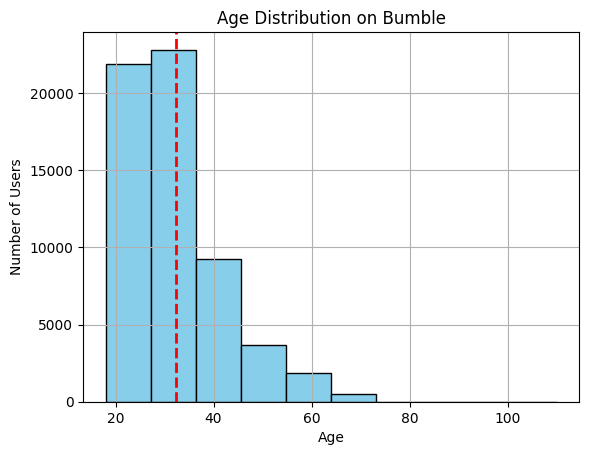

In [48]:
from matplotlib import pyplot as plt
import seaborn as sns
mean_age =bumble["age"].mean()

plt.hist(bumble["age"], bins=10, color='skyblue', edgecolor='black')
plt.axvline(mean_age, color='red', linestyle='--', linewidth=2, label=f'Mean Age: {mean_age:.1f}')
plt.title("Age Distribution on Bumble")
plt.xlabel("Age")
plt.ylabel("Number of Users")
plt.grid(True)
plt.show()

**Chart Result Analysis**

* The distribution is right-skewed, indicating that most users are younger.

* The highest concentration of users is between the ages of 18 and 30.

* The mean age (shown by the red dashed line) is around 30 years, but due to the skewness, most users are younger than the mean.

* A small number of users are above 50, and very few are above 60, indicating that the platform is primarily popular among younger adults.

**Q2. How does the age distribution differ by gender? Are there age groups where one gender is more prevalent?**

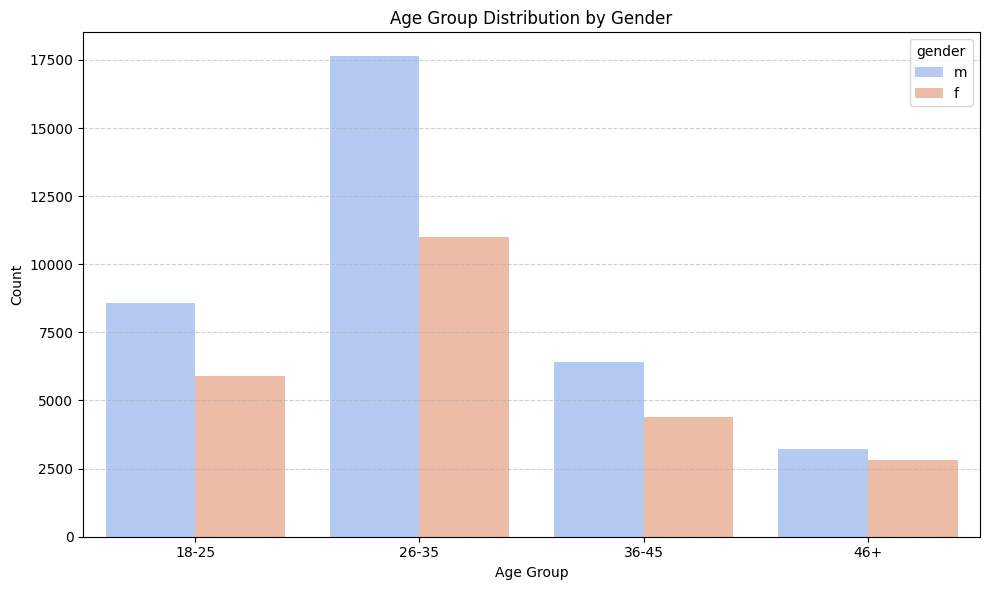

In [49]:
plt.figure(figsize=(10,6))
sns.countplot(data=bumble, x="age_group", hue="gender",  palette="coolwarm")

plt.title("Age Group Distribution by Gender")
plt.xlabel("Age Group")
plt.ylabel("Count")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Chart Result Analysis**

Yes, there are age groups where one gender is more prevalent:

* In the 18-25 age group, males are significantly more prevalent than females.

* In the 26-35 age group, males are still more prevalent, but the gap narrows slightly.

* The 36-45 age group shows a more balanced distribution, but males are still slightly more than females.

* The 46+ age group is almost balanced between males and females.

**Overall, males are more prevalent in the younger age groups (18-35), while the gender distribution becomes more balanced in older age groups.**

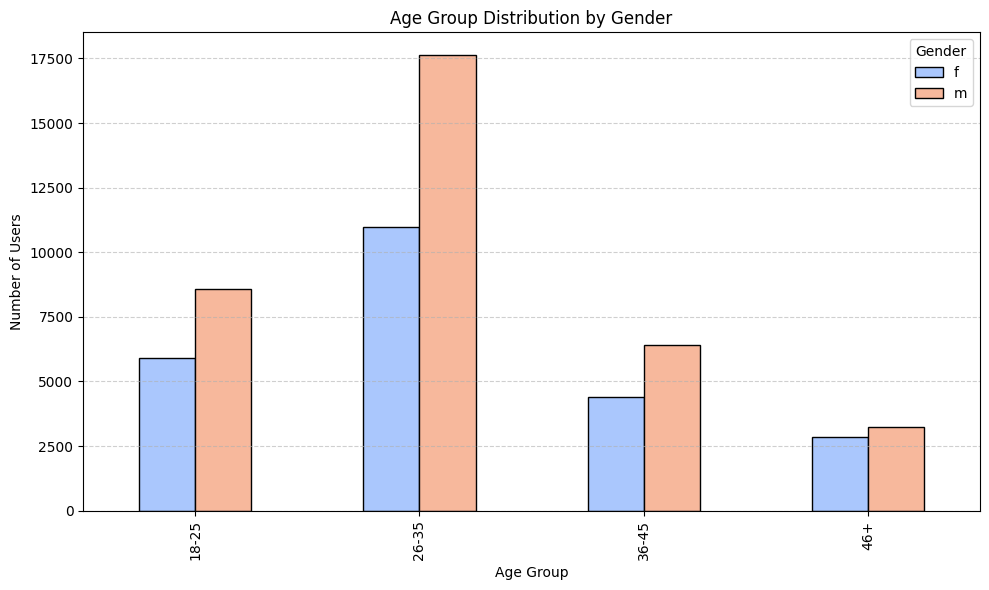

In [50]:
#ALTERNATIVE APPROACH CAN BE THIS TOO
# Create a cross-tab (pivot) of counts
age_gender_counts = bumble.groupby(["age_group", "gender"]).size().unstack()

# Plot as a grouped bar chart
colors = sns.color_palette("coolwarm", n_colors=age_gender_counts.shape[1])
age_gender_counts.plot(kind="bar", figsize=(10, 6), edgecolor='black', color=colors)

plt.title("Age Group Distribution by Gender")
plt.xlabel("Age Group")
plt.ylabel("Number of Users")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.legend(title="Gender")
plt.tight_layout()
plt.show()

###2. Income and Age
Visualizing the relationship between income and age helps uncover patterns in reported income levels across age groups, which could inform user segmentation strategies.

**Questions:**

**Q1. Use a scatterplot to visualize the relationship between income and age, with a trend line indicating overall patterns. Are older users more likely to report higher incomes?**

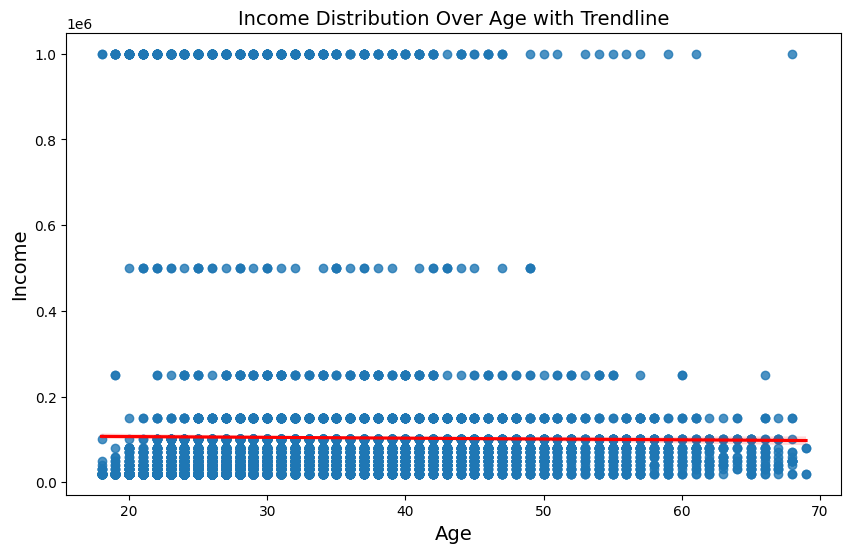

In [51]:
plt.figure(figsize=(10, 6))
sns.regplot(data=bumble[bumble['income']>0], x='age', y='income', line_kws={'color': 'red'})
plt.xlabel('Age',fontsize =14)
plt.ylabel('Income',fontsize =14)
plt.title('Income Distribution Over Age with Trendline',fontsize =14)
plt.show()

**Chart Result Analysis**

* The red trendline is almost flat, indicating no strong relationship between age and income.

* While there are a few high-income outliers in various age groups, most users, regardless of age, report lower incomes.

* Older users are not significantly more likely to report higher incomes than younger users.

* The lack of a clear upward slope suggests that income does not consistently increase with age among the users in this dataset.

**Q2. Create boxplots of income grouped by age_group. Which age group reports the highest median income?**

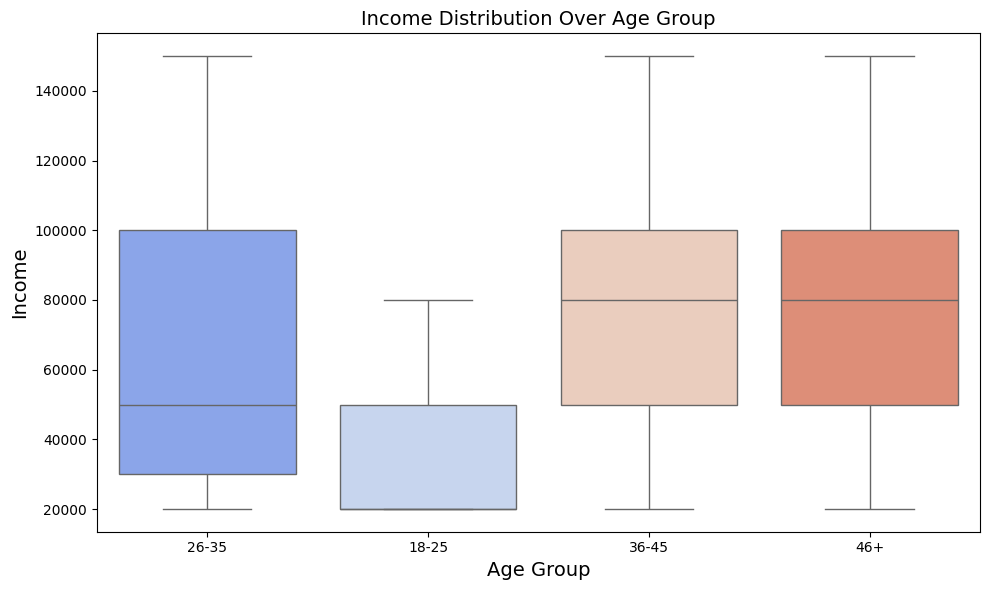

In [52]:
plt.figure(figsize=(10, 6))
sns.boxplot(
    data=bumble[bumble['income'] > 0],
    x="age_group",
    y='income',
    hue="age_group",
    showfliers=False,
    palette="coolwarm",
    dodge=False
)
plt.xlabel('Age Group', fontsize=14)
plt.ylabel('Income', fontsize=14)
plt.title('Income Distribution Over Age Group', fontsize=14)
plt.legend([], [], frameon=False)  # Remove redundant legend
plt.tight_layout()
plt.show()

**Chart Result Analysis**

* The 26-35 age group reports the highest median income, with a median value significantly above the other groups.

* The 46+ age group has the second highest median income, but it is slightly lower than the 26-35 group.

* The 36-45 age group has a lower median income compared to the 26-35 and 46+ groups.

* The 18-25 age group has the lowest median income, with a much smaller interquartile range, indicating less variation in income within this group.

* Overall, the 26-35 age group stands out as having the highest earnings, likely reflecting a period of peak earning potential for many individuals.

**Q3. Analyze income levels within gender and status categories. For example, are single men more likely to report higher incomes than single women?**

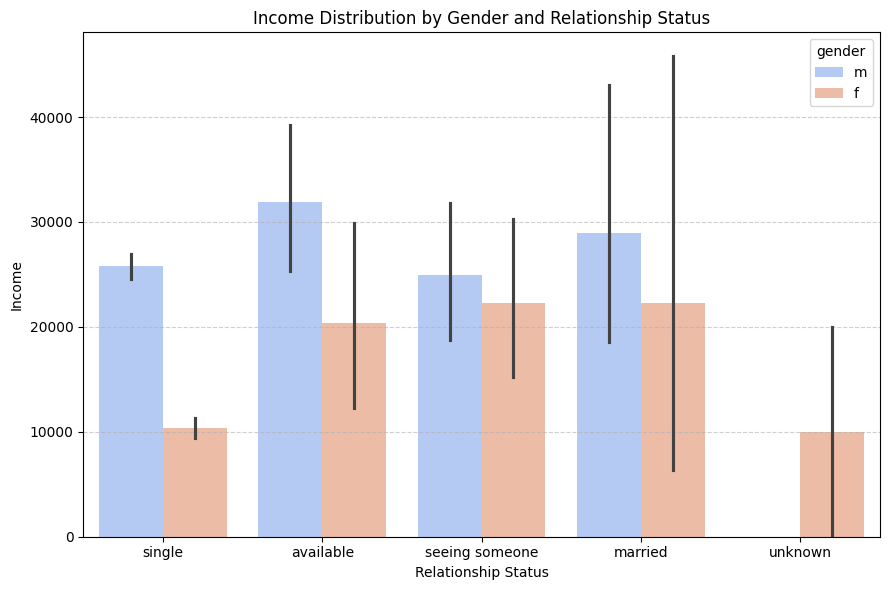

In [53]:
# Boxplot of income by gender and status
plt.figure(figsize=(9,6))

sns.barplot(data=bumble, x="status", y="income", hue="gender",  palette="coolwarm")

plt.title("Income Distribution by Gender and Relationship Status")
plt.xlabel("Relationship Status")
plt.ylabel("Income")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Chart Result Analysis**

* Single men report higher incomes on average compared to single women.

* For the available status, men have higher average incomes than women, and their income range is more spread out (higher variation).

* Among those seeing someone, the income levels between men and women are more balanced, but men still have slightly higher incomes.

* Married men report higher incomes than married women, with a wide range of income variation among married men.

* For the unknown relationship status, the income for women appears slightly higher, but this group has the lowest average income overall.

* In general, men tend to report higher incomes than women across all relationship status categories.

###3. Pets and Preferences

Pets are often a key lifestyle preference and compatibility factor. Analyzing how pets preferences distribute across demographics can provide insights for filters or recommendations.

**Questions:**

**Q1. Create a bar chart showing the distribution of pets categories (e.g., likes dogs, likes cats). Which preferences are most common?**

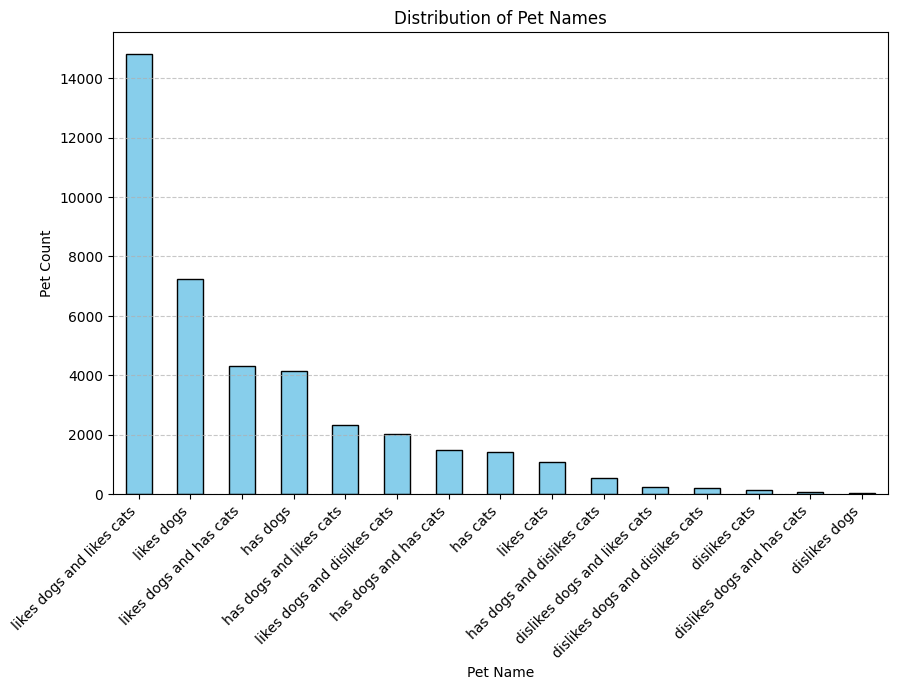

In [54]:
# Count each pet name
bumble["pets"].value_counts().plot(kind="bar", figsize=(10, 6), color='skyblue', edgecolor='black')

plt.xlabel("Pet Name")
plt.ylabel("Pet Count")
plt.title("Distribution of Pet Names")
plt.xticks(rotation=45, ha='right')
plt.grid(True, axis='y', linestyle='--', alpha=0.7)

**Chart Result Analysis**

* The most common preference is likes dogs and likes cats, with a significantly higher count than any other category.

* Likes dogs is the second most common preference.

* Has dogs and has cats and has dogs are also popular categories.

* Preferences involving disliking either dogs or cats are the least common, suggesting that most users are generally pet-friendly.

* Users who dislike pets (either dogs or cats) represent a minimal portion of the population.

* This distribution suggests a strong preference for users who are open to both dogs and cats.

**Q2. How do pets preferences vary across gender and age_group? Are younger users more likely to report liking pets compared to older users?**

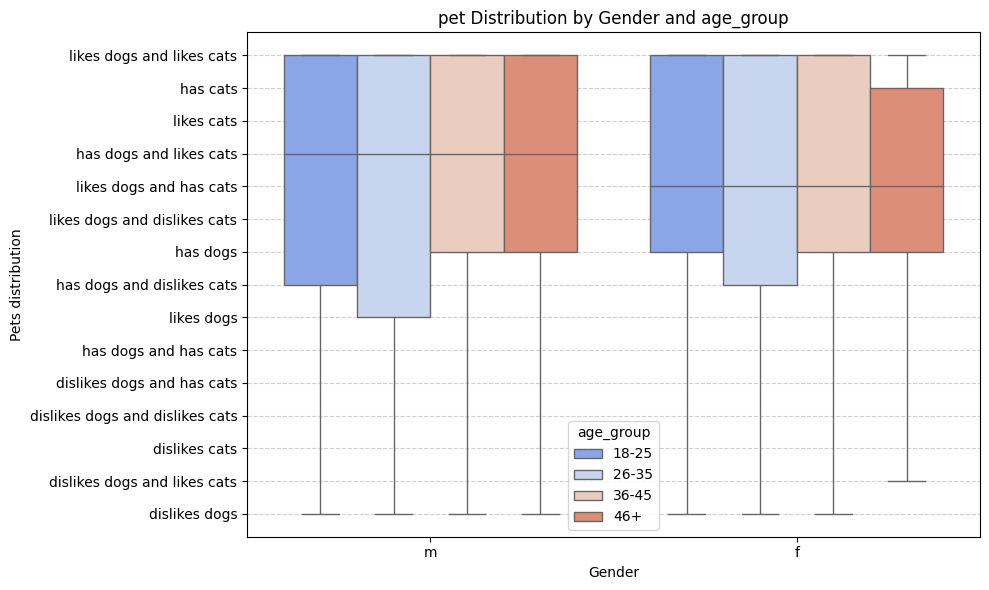

In [55]:
# Boxplot of income by gender and status
plt.figure(figsize=(10,6))
sns.boxplot(data=bumble, x="gender", y="pets", hue="age_group", palette="coolwarm")

plt.title("pet Distribution by Gender and age_group")
plt.xlabel("Gender")
plt.ylabel("Pets distribution")
plt.grid(True, axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

**Chart Result Analysis**

* Pet Preferences by Gender: Both men and women show a strong preference for likes dogs and likes cats.

**Pet Preferences by Age Group:**

-- Younger users (18-25) are more likely to prefer a mix of likes dogs and likes cats.

-- The 26-35 age group maintains similar preferences, but there is a noticeable increase in those who own pets (e.g., "has dogs and has cats").

-- Users aged 36-45 and 46+ have more diverse preferences, with a slight increase in users who prefer specific pets or dislike one type.

* Overall Trend: Younger users are more likely to express broader pet preferences (liking both dogs and cats), while older users are slightly more varied in their choices.

###4. Signs and Personality

Users’ self-reported zodiac signs (sign) can offer insights into personality preferences or trends. While not scientifically grounded, analyzing this data helps explore fun and engaging patterns.

**Questions:**

**Q1. Create a pie chart showing the distribution of zodiac signs (sign) across the platform. Which signs are most and least represented? Is this the right chart? If not, replace with right chart.**

Text(0.5, 1.0, 'Distribution of Zodiac Signs')

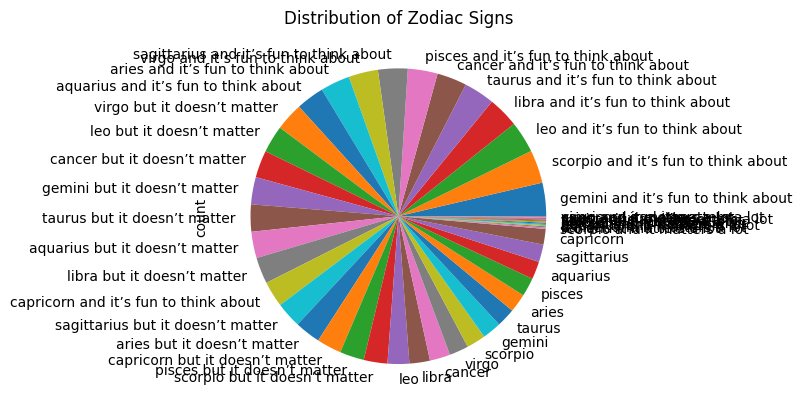

In [58]:
zodiac_counts = bumble["sign"].value_counts()
zodiac_counts.plot(kind='pie')
plt.title("Distribution of Zodiac Signs")

**Chart Result Analysis**
**The current pie chart has several issues:**

* Overlapping Text Labels: The text is cluttered, making it nearly unreadable.

* Excessive Labels: Labels are too descriptive (e.g., "it's fun to think about"), which isn't suitable for a clean visualization.

* Poor Color Distinction: Too many colors make it hard to focus on any particular sign.

**This is not the correct chart fot the analysis**

Text(0.5, 1.0, 'Distribution of Zodiac Signs')

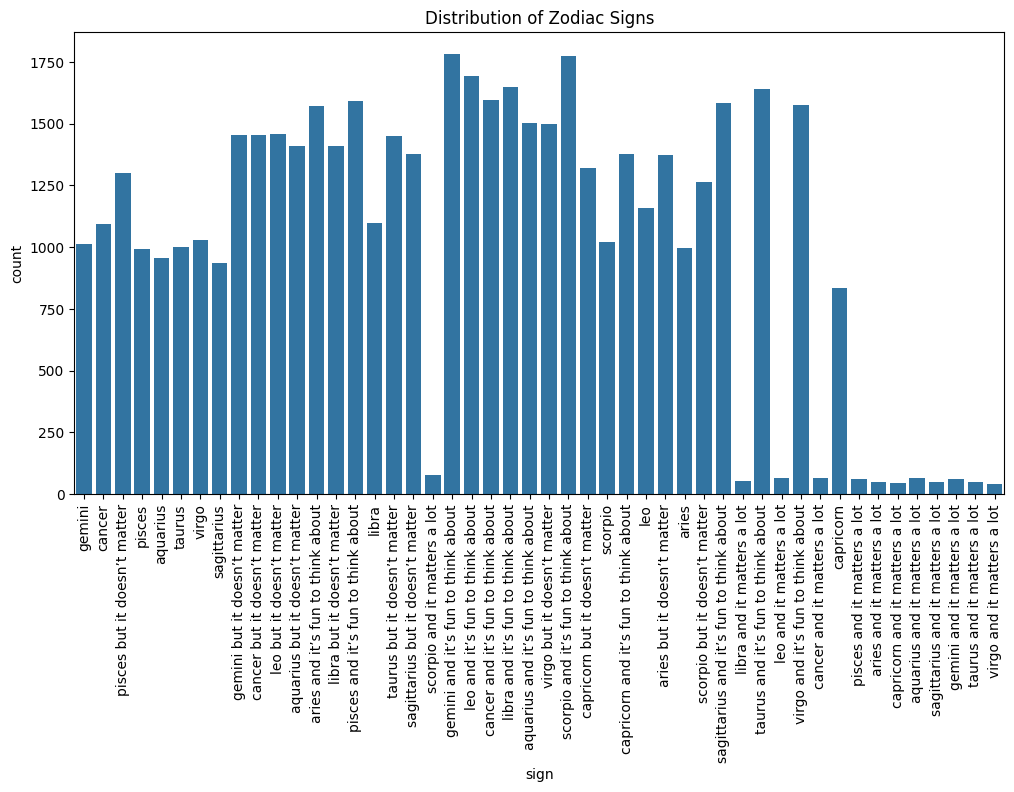

In [59]:
plt.figure(figsize=(12,6))
sns.countplot(data= bumble , x = "sign")
plt.xticks(rotation = 90)
plt.title("Distribution of Zodiac Signs")

**Q2. How does sign vary across gender and status? Are there noticeable patterns or imbalances?**

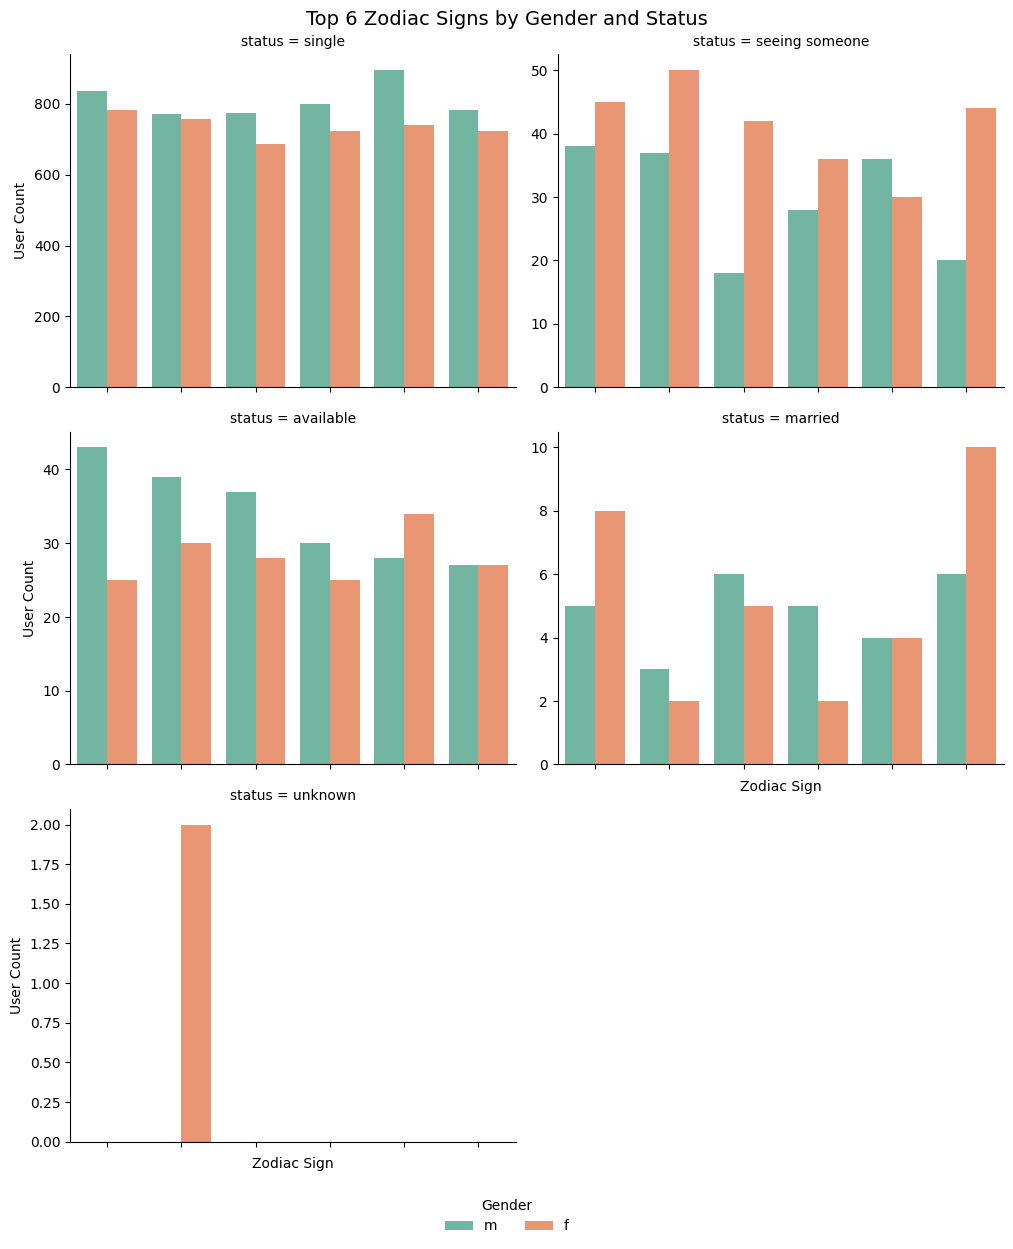

In [60]:
# Get top 6 most common signs
top_signs = bumble["sign"].value_counts().head(6).index
filtered_bumble = bumble[bumble["sign"].isin(top_signs)]
g = sns.catplot(
    data=filtered_bumble,
    x="sign",
    hue="gender",
    col="status",
    kind="count",
    col_wrap=2,
    height=4,
    aspect=1.2,
    palette="Set2",
    sharey=False
)
g.set_xticklabels(rotation=45)
g.set_axis_labels("Zodiac Sign", "User Count")
g.fig.subplots_adjust(top=0.88)
g._legend.remove()
g.fig.legend(
    title="Gender",
    loc='lower center',
    ncol=2,
    bbox_to_anchor=(0.5, -0.05),
    frameon=False
)
g.fig.suptitle("Top 6 Zodiac Signs by Gender and Status", fontsize=14)
plt.tight_layout()
plt.show()

In [61]:
# Create your crosstab (already done)
ct = pd.crosstab(index=bumble["sign"], columns=[bumble["gender"], bumble["status"]])

# Define the style function
def style_multiindex_headers(styler):
    styler.set_table_styles([
        {'selector': 'th.col_heading.level0',
         'props': [('border-right', '2px solid black'),
                   ('background-color', '#d1e0e0'),
                   ('font-weight', 'bold'),
                   ('border-bottom', '2px solid black')]},
        {'selector': 'th.col_heading.level1',
         'props': [('background-color', '#f2f2f2'),
                   ('font-weight', 'bold')]},
        {'selector': 'th.row_heading.level0',
         'props': [('font-weight', 'bold')]},
        {'selector': 'td',
         'props': [('border', '1px solid #ccc')]}
    ], overwrite=True)
    return styler

styled_ct = ct.style.pipe(style_multiindex_headers).set_caption("Zodiac Signs by Gender and Status")
display(styled_ct)

📊 **Conclusion: Insights from Bumble User Analysis**

This multi-faceted analysis of the Bumble dataset reveals several key insights across age, income, pet preferences, and zodiac signs:

🧓 **Income & Age:**

* There is no strong correlation between age and income, as indicated by the flat regression trendline.
* The 26–35 age group reports the highest median income, followed by the 46+ group.
* Across gender and relationship status, men tend to report higher incomes than women, particularly among single and married users.

🐶 **Pets & Preferences:**
* The most popular pet preference is “likes dogs and likes cats”, highlighting strong overall pet friendliness.
* Younger users (18–25) favor liking both cats and dogs, while older users show more variation, including ownership and stronger preferences.
* Gender differences are minimal, with both men and women showing high affinity for pets.

♌ **Signs & Personality:**
* The original pie chart was replaced by a more readable bar chart, better suited for visualizing zodiac sign distribution.
* Signs such as Leo, Scorpio, and Virgo are among the most represented.
* When segmented by gender and relationship status, no drastic imbalance is observed, though some variations exist across the top signs.

---

Overall, this analysis provides valuable demographic and behavioral segmentation clues. These insights could enhance personalization strategies, improve match recommendations, and support targeted marketing or user experience design within dating platforms like Bumble.